# GWR Analysis


### 4.0 Notebook Setup and Inputs
This notebook builds the modeling table for spatial regression between older-adult travel time, POI infrastructure, population, and aging-growth pressure. It reads raw POI and slope layers plus processed travel-time and population outputs, then prepares GWR and global regression diagnostics.


In [9]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

try:
    import statsmodels.api as sm
except ImportError:
    sm = None

try:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW
except ImportError:
    GWR = None
    Sel_BW = None


In [10]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../data/output")
# Create a separate output folder for model artifacts so raw and processed inputs remain unchanged.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

poi_gdf = gpd.read_file(RAW_DIR / "hexagon_poi_statistics.gpkg")
ts_slope_gdf = gpd.read_file(RAW_DIR / "ts_slope_elderly.gpkg")
facility_distance_time = pd.read_csv(PROCESSED_DIR / "facility_distance_time.csv")
pop_corrected = pd.read_csv(PROCESSED_DIR / "pop_corrected.csv")
sz_boundary = gpd.read_file(RAW_DIR / "sz_boundary.shp")


## Model Dataset


### 4.1 Model Dataset Assembly
This section joins POI attributes, corrected older-adult population, average older-adult travel time, and Theil-Sen aging slope by hexagon Id. The resulting GeoDataFrame is the shared modeling surface for GWR and global regression checks.


In [11]:
# Keep only the older-adult population field needed as a modeling covariate.
base_columns = ["Id", "old_2020_sum"]
# Use older-adult average travel time as the model target.
time_columns = ["Id", "elder_time_avg_distance"]

# Merge all modeling covariates on hexagon Id to preserve the POI geometry.
gdf_final = poi_gdf.merge(
    pop_corrected[base_columns],
    on="Id",
    how="left",
).merge(
    facility_distance_time[time_columns],
    on="Id",
    how="left",
).merge(
    ts_slope_gdf[["Id", "ts_slope"]],
    on="Id",
    how="left",
)

# Keep a compatibility alias for older logic that expected this label.
# Add compatibility aliases for Phase 1 English column-name changes.
if "Life" in gdf_final.columns and "Daily life" not in gdf_final.columns:
    gdf_final["Daily life"] = gdf_final["Life"]
if "Culture" in gdf_final.columns and "Cultural" not in gdf_final.columns:
    gdf_final["Cultural"] = gdf_final["Culture"]

# Reproject Shenzhen boundary to the model CRS before overlay plotting.
if gdf_final.crs is not None and sz_boundary.crs != gdf_final.crs:
    sz_boundary = sz_boundary.to_crs(gdf_final.crs)

gdf_final.head()


,Id,Transportation,Sports,Healthcare,Government,Life,Culture,Shopping,Tourist,Food,Total_POI_Count,POI_Variety,geometry,old_2020_sum,elder_time_avg_distance,ts_slope,Daily life,Cultural
0,0,0,1,5,3,1,0,6,0,11,27,6,"MULTIPOLYGON (((822333.448 2504826.051, 822133...",223.081048,17.716089,9.546200,1,0
1,1,0,5,13,2,7,14,10,7,55,113,8,"MULTIPOLYGON (((822033.448 2503960.025, 821833...",411.883761,11.608294,17.625542,7,14
2,2,0,0,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((864733.448 2495819.386, 864633...",0.000000,193.285305,0.000000,0,0
3,3,0,0,0,0,0,0,0,0,0,0,0,"MULTIPOLYGON (((864633.448 2507424.127, 864433...",0.000000,NaN,0.000000,0,0
4,4,0,1,0,0,0,0,0,0,0,1,1,"MULTIPOLYGON (((829533.448 2512100.664, 829333...",95.865872,44.046146,9.772560,0,0


In [15]:
gdf_final.columns


Index(['Id', 'Transportation', 'Sports', 'Healthcare', 'Government', 'Life',
       'Culture', 'Shopping', 'Tourist', 'Food', 'Total_POI_Count',
       'POI_Variety', 'geometry', 'old_2020_sum', 'elder_time_avg_distance',
       'ts_slope', 'Daily life', 'Cultural'],
      dtype='str')

In [25]:
import geopandas as gpd
sz_boundary = gpd.read_file(RAW_DIR / "sz_boundary.shp")
if sz_boundary.crs != gdf_final.crs:
    sz_boundary = sz_boundary.to_crs(gdf_final.crs)

print(gdf_modelable.crs)
print(sz_boundary.crs)
print(gdf_modelable.total_bounds)
print(sz_boundary.total_bounds)



EPSG:32649
EPSG:32649
[ 784233.44763898 2487332.33735924  863233.44822654 2527342.71131167]
[ 783233.44763104 2484907.46621066  873290.08446886 2531122.58843368]


### GWR model

### 4.2 Geographically Weighted Regression Model
This section fits a local GWR model for older-adult travel time using infrastructure variables and aging-pressure slope. It filters unusable hexagons, standardizes features, selects an adaptive bandwidth, and maps dominant local factors and model fit.


数据准备完毕。 GWR 将在 8114 行上运行。
准备 GWR: 8114 个格网, 11 个自变量。
正在搜索最优带宽 (这可能需要几分钟，请耐心等待)...


/opt/miniconda3/envs/geoenv/lib/python3.11/site-packages/spglm/iwls.py:37: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.185831927501079e-18.
  xtx_inv_xt = linalg.solve(xtx, xT)


搜索完成。最优带宽 (邻居数 k): 160.0
正在运行 GWR 模型...
GWR 模型运行完成。

--- GWR 全局诊断信息 (Global Diagnostics) ---
Model type                                                         Gaussian
Number of observations:                                                8114
Number of covariates:                                                    12

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           4454.898
Log-likelihood:                                                   -9080.744
AIC:                                                              18185.488
AICc:                                                             18187.533
BIC:                                                             -68474.009
R2:                                                                   0.451
Adj. R2:                                                              0.450

Variable                              Est. 

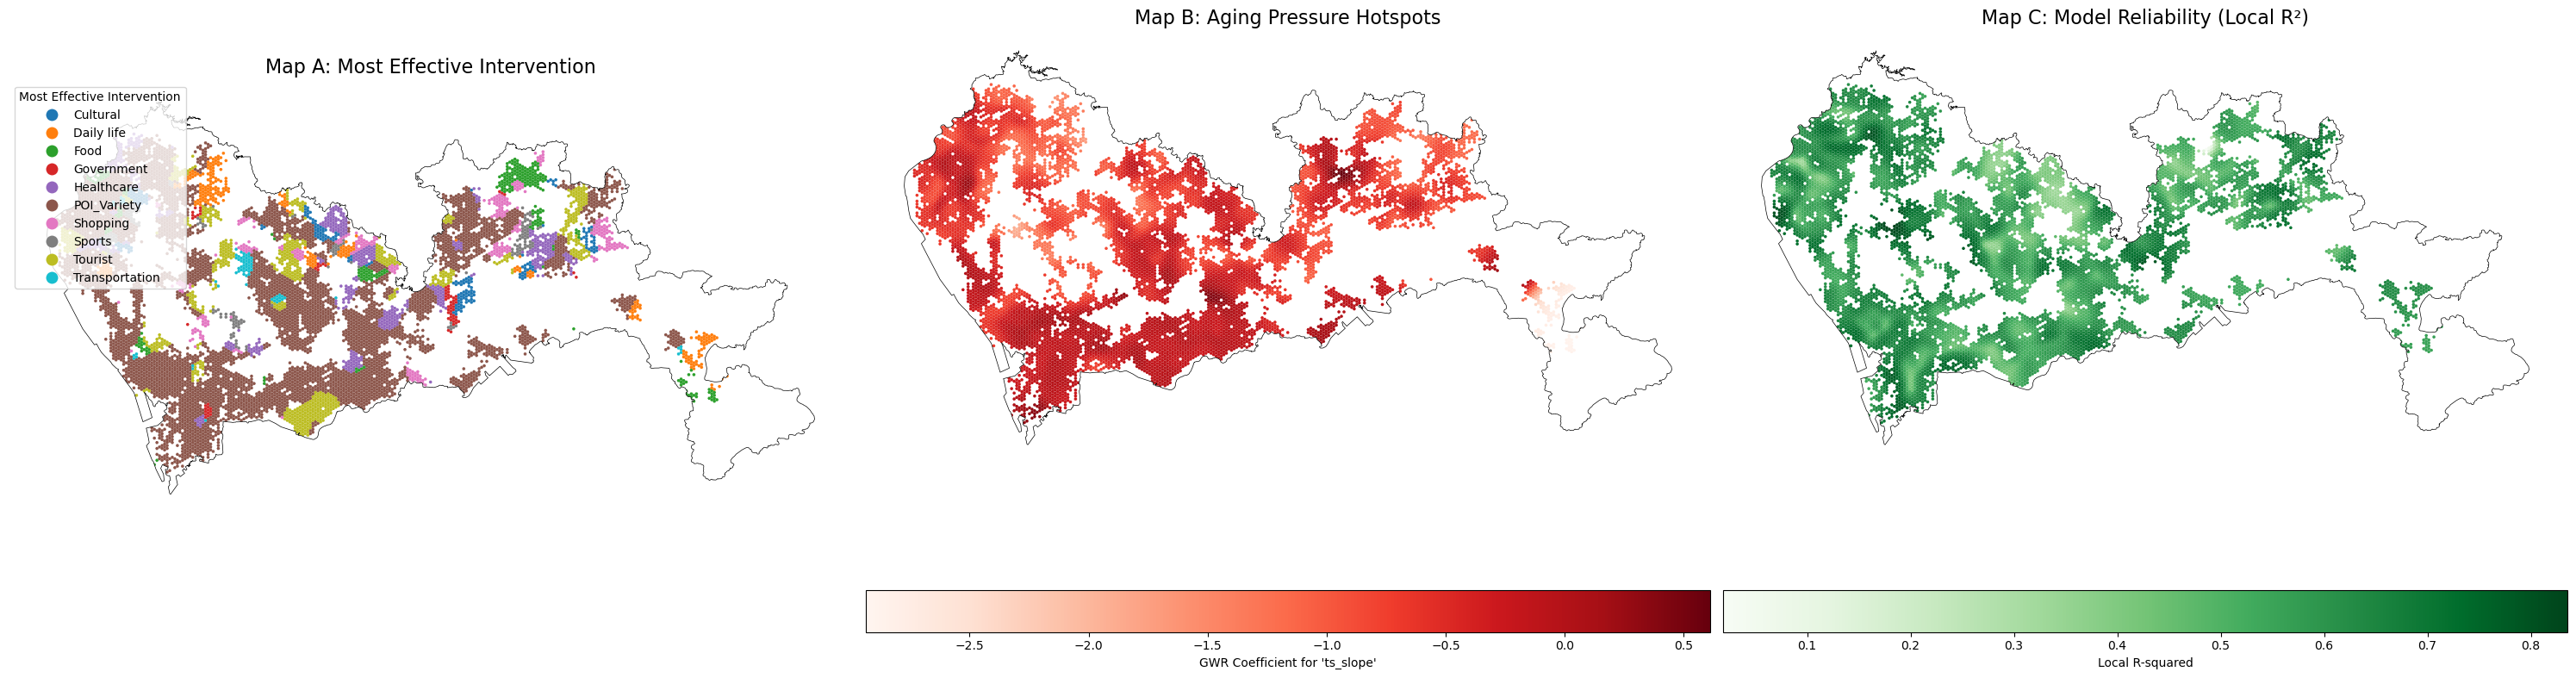

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import mgwr
from sklearn.preprocessing import StandardScaler
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW # "Sel_BW" = Select Bandwidth (选择带宽)
import matplotlib.pyplot as plt

# 假设 `gdf_final` 是您最原始的、包含所有数据的 GeoDataFrame
# (在您的环境中，gdf_final 应该已经加载)
#
# 假设 `sz_street_dissolve` 也已加载，用于绘制底图
# try:
#     sz_street_dissolve = gpd.read_file("data/sz_street_2_Dissolve_polygon.shp")
# except Exception:
#     sz_street_dissolve = None # 如果找不到，就设置为空

# --- 1. 数据准备 ---
FEATURES = [
    # 10 个可干预的基础设施变量 (Intervention Levers)
    'Transportation', 'Sports', 'Healthcare', 'Government',
    'Daily life', 'Cultural', 'Shopping', 'Tourist', 'Food',
    'POI_Variety',
    # 1 个背景压力变量 (Contextual Stressor)
    'ts_slope' 
]
TARGET = 'elder_time_avg_distance'

# COLUMNS_TO_CHECK defines the complete non-null set required before fitting GWR.
COLUMNS_TO_CHECK = FEATURES + [TARGET]

# 1. 过滤 NaN
# Drop hexagons missing any model feature or the travel-time target.
gdf_cleaned_nan = gdf_final.dropna(subset=COLUMNS_TO_CHECK)
# 2. 过滤 0-POI (假设您有 Total_POI_Count 列)
if 'Total_POI_Count' in gdf_cleaned_nan.columns:
    # Remove zero-POI hexagons because infrastructure coefficients are not interpretable there.
    gdf_cleaned_poi = gdf_cleaned_nan[gdf_cleaned_nan['Total_POI_Count'] > 0]
else:
    print("警告: 未找到 'Total_POI_Count' 列，跳过 0-POI 过滤。")
    gdf_cleaned_poi = gdf_cleaned_nan
    
# 3. 过滤 Time < 60 (您代码中用的是60)
# Restrict modeling to hexagons below 60 minutes to reduce extreme travel-time influence.
gdf_modelable = gdf_cleaned_poi[gdf_cleaned_poi[TARGET] < 60].copy()

if gdf_modelable.empty:
    print("错误：经过所有筛选 (NaN, 0-POI, Time<60) 后，没有剩余数据。")
else:
    print(f"数据准备完毕。 GWR 将在 {len(gdf_modelable)} 行上运行。")

    # 1a. 提取 X 和 y
    X = gdf_modelable[FEATURES]
    y = gdf_modelable[TARGET]

    # 1b. 提取坐标
    u = gdf_modelable.geometry.centroid.x
    v = gdf_modelable.geometry.centroid.y
    # GWR uses hexagon centroid coordinates to estimate spatially varying coefficients.
    coords = np.array(list(zip(u, v))) 

    # 1c. 标准化 (您的代码已正确执行此操作)
    scaler_X = StandardScaler()
    # Standardize predictors so local coefficients are comparable across different units.
    X_scaled = scaler_X.fit_transform(X)
    scaler_y = StandardScaler()
    y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)) 

    print(f"准备 GWR: {len(X_scaled)} 个格网, {X_scaled.shape[1]} 个自变量。")

    # --- 2. 寻找最优带宽 (Bandwidth) ---
    print("正在搜索最优带宽 (这可能需要几分钟，请耐心等待)...")
    
    # 使用自适应带宽 (fixed=False)
    bw_selector = Sel_BW(coords, y_scaled, X_scaled,
                         # fixed=False selects an adaptive nearest-neighbor bandwidth for uneven spatial density.
fixed=False, 
                         # Bisquare kernel downweights distant neighbors and gives compact local influence.
kernel='bisquare')
    
    best_k_neighbors = bw_selector.search() 
    
    print(f"搜索完成。最优带宽 (邻居数 k): {best_k_neighbors}")

    # --- 3. 运行 GWR 模型 ---
    print("正在运行 GWR 模型...")
    
    gwr_model = GWR(coords, y_scaled, X_scaled,
                    bw=best_k_neighbors,
                    fixed=False, 
                    kernel='bisquare',
                    constant=True) # constant=True 会添加一个截距项
    
    gwr_results = gwr_model.fit()
    print("GWR 模型运行完成。")

    # --- 4. 查看全局结果 (可选) ---
    print("\n--- GWR 全局诊断信息 (Global Diagnostics) ---")
    print(gwr_results.summary())

    # -----------------------------------------------------------------
    # --- 5. (新增) 处理 GWR 结果以制作决策地图 ---
    # -----------------------------------------------------------------
    print("\n--- 5. 正在处理 GWR 结果以制作决策地图 ---")

    # 5.1. 将 GWR 结果 (局部系数) 放入一个 DataFrame
    # GWR 结果的列顺序: Intercept (截距), 然后是 FEATURES 中的变量
    gwr_param_columns = ['Intercept'] + FEATURES
    
    # 关键: 使用 gdf_modelable.index
    # 这确保了系数与原始的 GeoDataFrame 完美对齐
    coeff_df = pd.DataFrame(gwr_results.params, 
                            columns=gwr_param_columns, 
                            index=gdf_modelable.index)

    # 5.2. 找出“最有效的干预措施” (地图 A)
    
    # 定义哪些是我们可以干预的 (基础设施)
    # 我们从 FEATURES 中排除了 'ts_slope'
    intervention_vars = [
        'Transportation', 'Sports', 'Healthcare', 'Government',
        'Daily life', 'Cultural', 'Shopping', 'Tourist', 'Food',
        'POI_Variety'
    ]
    
    # 解释: 
    # 我们的因变量 (Y) 是 'elder_time_avg_distance' (出行时间)
    # 我们希望 *减少* 出行时间。
    # 因此，一个“有效”的干预措施会有一个 *负* 的系数 (增加设施 -> 减少时间)
    # “最有效”的干预措施 = 具有 *最小 (最负)* 系数的变量
    
    # .idxmin(axis=1) 会返回每行中具有最小值的列的 *名称*
    # Dominant_Factor is the intervention variable with the most negative local coefficient.
    gdf_modelable['Dominant_Factor'] = coeff_df[intervention_vars].idxmin(axis=1)

    # 5.3. 找出“老龄化压力区” (地图 B)
    # 这就是 'ts_slope' 变量的局部系数值
    # 一个高的正系数值意味着: "在此处，老年人口的增加会极大地增加出行时间"
    # Aging_Pressure_Coeff captures the local association between aging-growth pressure and travel time.
    gdf_modelable['Aging_Pressure_Coeff'] = coeff_df['ts_slope']
    
    # 5.4. (推荐) 找出模型可靠性 (局部 R-squared)
    # 这告诉我们 GWR 模型在每个格网的解释力
    gdf_modelable['Local_R2'] = gwr_results.localR2
    
    print("决策地图数据处理完毕，已合并回 GeoDataFrame。")
    print(gdf_modelable[['Dominant_Factor', 'Aging_Pressure_Coeff', 'Local_R2']].head())


    # -----------------------------------------------------------------
    # --- 6. (新增) 绘制两张决策地图 ---
    # -----------------------------------------------------------------
    print("\n--- 6. 正在绘制决策地图 ---")

    # 创建一个 1x3 的图布 (干预图, 压力图, R2图)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(30, 10))
    
    # --- 地图 A: 最有效干预图 ---
    gdf_modelable.plot(
        column='Dominant_Factor', 
        ax=ax1, 
        categorical=True,  # 这是一个分类图
        legend=True,
        legend_kwds={'title': "Most Effective Intervention", 'loc': 'upper left'}
    )
    # (可选) 叠加街道边界
    if sz_boundary is not None:
        sz_boundary.plot(ax=ax1, color='none', edgecolor='black', linewidth=0.5)
        
    ax1.set_title('Map A: Most Effective Intervention', fontsize=16)
    ax1.set_axis_off()

    # --- 地图 B: 老龄化压力图 ---
    gdf_modelable.plot(
        column='Aging_Pressure_Coeff', 
        ax=ax2, 
        cmap='Reds', # 使用红色渐变，越红 = 压力越大
        legend=True,
        legend_kwds={'label': "GWR Coefficient for 'ts_slope'", 'orientation': "horizontal"}
    )
    if sz_boundary is not None:
        sz_boundary.plot(ax=ax2, color='none', edgecolor='black', linewidth=0.5)

    ax2.set_title('Map B: Aging Pressure Hotspots', fontsize=16)
    ax2.set_axis_off()

    # --- (推荐) 地图 C: 模型可靠性 (Local R²) ---
    gdf_modelable.plot(
        column='Local_R2', 
        ax=ax3, 
        cmap='Greens', # 越绿 = 模型解释力越强
        legend=True,
        legend_kwds={'label': "Local R-squared", 'orientation': "horizontal"}
    )
    if sz_boundary is not None:
        sz_boundary.plot(ax=ax3, color='none', edgecolor='black', linewidth=0.5)

    ax3.set_title('Map C: Model Reliability (Local R²)', fontsize=16)
    ax3.set_axis_off()

    plt.tight_layout()
    plt.show()


## Random Forest model


### 4.3 Global Regression and Machine-Learning Checks
These sections provide non-spatial or global model checks against the same target variable. They help compare local GWR patterns with global OLS, random forest importance, and standardized linear coefficients.


In [ ]:
# OLS_FEATURES mirrors the core infrastructure and aging-pressure variables for a global comparison model.
OLS_FEATURES = [
    "Transportation", "Sports", "Healthcare", "Government", "Life",
    "Culture", "Shopping", "Tourist", "Food", "Total_POI_Count", "ts_slope",
]
TARGET = "elder_time_avg_distance"

# Drop incomplete rows before fitting the global OLS model.
ols_data = gdf_final.dropna(subset=OLS_FEATURES + [TARGET]).copy()
# Match the GWR travel-time filter for comparability.
ols_data = ols_data[ols_data[TARGET] < 60]
if "Total_POI_Count" in ols_data.columns:
    # Match the GWR zero-POI filter for comparability.
    ols_data = ols_data[ols_data["Total_POI_Count"] > 0]

if sm is None:
    print("statsmodels is not installed; skipping OLS fit.")
else:
    X = sm.add_constant(ols_data[OLS_FEATURES])
    y = ols_data[TARGET]
    ols_model = sm.OLS(y, X).fit()
    print(ols_model.summary())


                               OLS Regression Results                              
Dep. Variable:     elder_time_avg_distance   R-squared:                       0.393
Model:                                 OLS   Adj. R-squared:                  0.393
Method:                      Least Squares   F-statistic:                     525.7
Date:                     Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                             14:35:53   Log-Likelihood:                -29111.
No. Observations:                     8114   AIC:                         5.824e+04
Df Residuals:                         8103   BIC:                         5.832e+04
Df Model:                               10                                         
Covariance Type:                 nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [30]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Raw inputs
results_gdf_pop_base = gpd.read_file(RAW_DIR / "results_gdf_pop.gpkg")
sz_street_dissolve_base = gpd.read_file(RAW_DIR / "sz_boundary.shp")
sz_street_dissolve_base.set_crs("EPSG:4326", allow_override=True, inplace=True)
hexagon_clip_base = gpd.read_file(RAW_DIR / "hexagon_clip.shp")
facility_distance_base = pd.read_csv(RAW_DIR / "facility_distance.csv")
hexagon_age_stats_base = pd.read_csv(RAW_DIR / "hexagon_age_stats.csv")
hexagon_ratio_base = pd.read_csv(RAW_DIR / "hexagon_ratio.csv")
pop_predict_base = gpd.read_file(RAW_DIR / "pop_predict.gpkg")
china_elderly_rate = pd.read_csv(RAW_DIR / "china_elderly_population.csv")
population_age_gender = pd.read_csv(RAW_DIR / "population_age_gender_20_35.csv")
hexagon_poi_statistics = gpd.read_file(RAW_DIR / "hexagon_poi_statistics.gpkg")
ts_slope_elderly = gpd.read_file(RAW_DIR / "ts_slope_elderly.gpkg", driver="GPKG")

# Processed notebook-generated intermediates
pop_predict_interpolated_all = gpd.read_file(PROCESSED_DIR / "pop_predict_interpolated_real.gpkg")
pop_predict_interpolated_2 = pop_predict_interpolated_all.copy()
gdf_final_control = gpd.read_file(PROCESSED_DIR / "pop_predict_control_world.gpkg")

# Shared figure data assembled once from loaded files
results_gdf = hexagon_poi_statistics.copy()
avg_distance_time_base = facility_distance_base[["Id", "labor_time_avg_distance", "elder_time_avg_distance"]].copy()
pop_2020_base = hexagon_age_stats_base.drop(columns=["geometry"], errors="ignore")[["Id", "child_2020_sum", "labor_2020_sum", "old_2020_sum"]].copy()
pop_2020_base["pop_2020"] = pop_2020_base[["child_2020_sum", "labor_2020_sum", "old_2020_sum"]].sum(axis=1)
pop_2020_base["elderly_ratio_2020"] = pop_2020_base["old_2020_sum"] / pop_2020_base["pop_2020"] * 100
avg_distance_time = hexagon_clip_base.merge(avg_distance_time_base, left_on="Id", right_on="Id", how="left")
avg_distance_time = avg_distance_time.merge(pop_2020_base, left_on="Id", right_on="Id", how="left")
merged_df = avg_distance_time

model_pois = results_gdf.merge(
    avg_distance_time[["Id", "old_2020_sum", "elder_time_avg_distance"]],
    left_on="Id",
    right_on="Id",
    how="left",
)
# Rename Phase 1 POI columns to the English labels expected by the figure/model code.
model_pois = model_pois.rename(columns={"Life": "Daily life", "Culture": "Cultural"})
model_pois = model_pois.merge(ts_slope_elderly[["Id", "ts_slope"]], left_on="Id", right_on="Id", how="left")
gdf_final = model_pois.copy()
gdf_sz = pop_predict_interpolated_2.copy()
gdf_control = gdf_final_control.copy()


/opt/miniconda3/envs/geoenv/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option DRIVER
  return ogr_read(


过滤 NaN 和 0-POI 后，剩余: 8825 行。
过滤 elder_time_avg_distance < 30 后，用于建模: 8114 行。

--- 正在训练 随机森林回归模型 ---
随机森林 R-squared (R2): 0.4510

随机森林 特征重要性排名:
POI_Variety       0.335179
ts_slope          0.261587
old_2020_sum      0.142408
Food              0.055450
Shopping          0.042356
Healthcare        0.037535
Daily life        0.028540
Government        0.027164
Transportation    0.025317
Sports            0.021401
Tourist           0.016343
Cultural          0.006723
dtype: float64


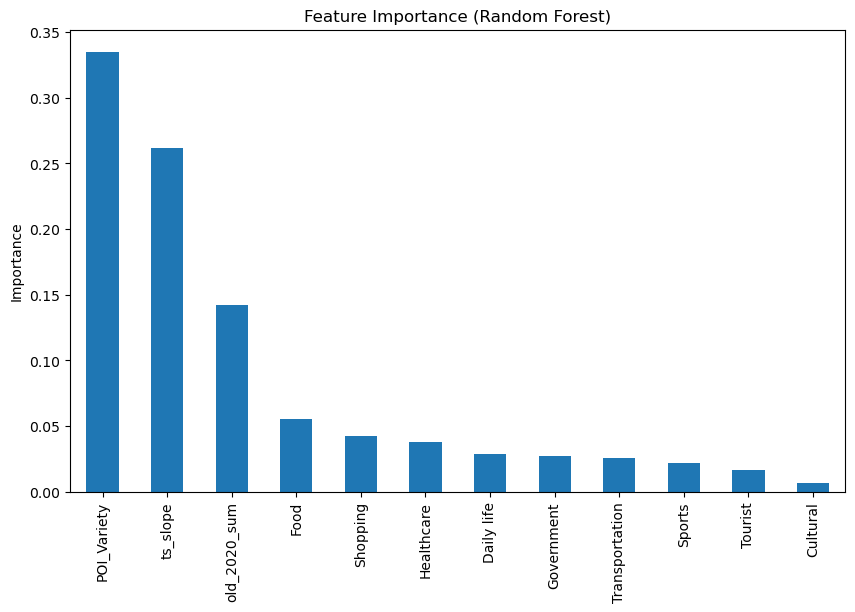


--- 正在训练 线性回归模型 ---
线性回归 R-squared (R2): 0.4744

线性回归 模型系数 (标准化后):
old_2020_sum       8.979197
Food               0.233879
Cultural          -0.147358
Transportation    -0.170149
Daily life        -0.197434
Shopping          -0.199685
Government        -0.269228
Sports            -0.283111
Tourist           -0.324976
Healthcare        -0.914242
POI_Variety       -3.770517
ts_slope         -11.992991
dtype: float64

模型截距 (Intercept): 25.9725


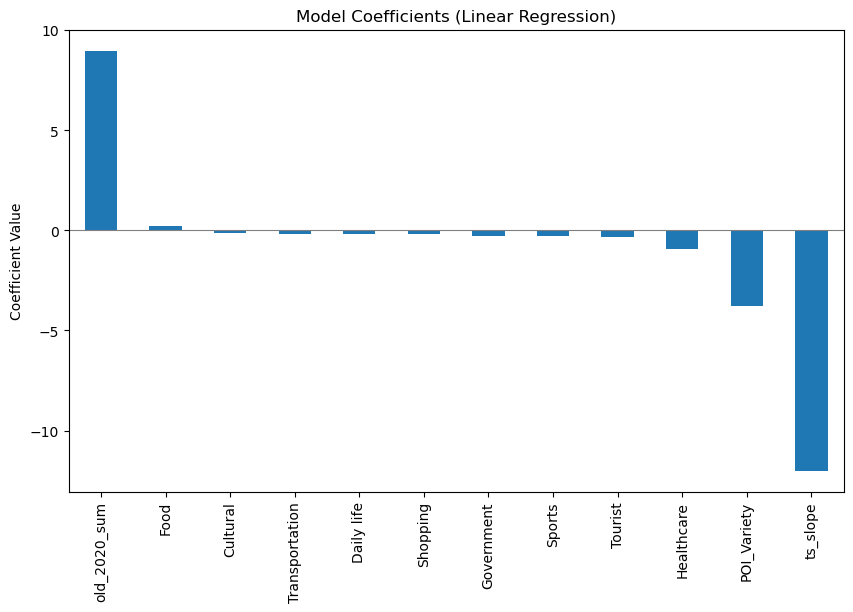

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Data preparation note

# DataFrame preparation note
# Missing-value handling note
hexagon_poi_statistics = gpd.read_file(RAW_DIR / "hexagon_poi_statistics.gpkg")
results_gdf = hexagon_poi_statistics.copy()

model_pois = results_gdf.merge(
    avg_distance_time[["Id", "old_2020_sum", "elder_time_avg_distance"]],
    left_on="Id",
    right_on="Id",
    how="left",
)
# Rename Phase 1 POI columns to the English labels expected by the figure/model code.
model_pois = model_pois.rename(columns={"Life": "Daily life", "Culture": "Cultural"})
model_pois = model_pois.merge(ts_slope_elderly[["Id", "ts_slope"]], left_on="Id", right_on="Id", how="left")

gdf_final = model_pois.copy()


# Data preparation note

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Data preparation note

# Translated comment
FEATURES = [
    'Transportation', 'Sports', 'Healthcare', 'Government',
    'Daily life', 'Cultural', 'Shopping', 'Tourist', 'Food',
    'POI_Variety',
    'old_2020_sum','ts_slope'
]
TARGET = 'elder_time_avg_distance'

# Translated comment
# COLUMNS_TO_MODEL collects all predictors and the target for the random-forest and linear-regression checks.
COLUMNS_TO_MODEL = FEATURES + [TARGET]

# Filtering note
# Translated comment
# DataFrame preparation note
temp_df = gdf_final[COLUMNS_TO_MODEL]

# Missing-value handling note
temp_df_cleaned = temp_df.dropna()

# POI filtering note
# POI filtering note
# Keep only hexagons with at least one POI before training non-spatial models.
poi_count_filter = gdf_final.loc[temp_df_cleaned.index, 'Total_POI_Count'] > 0
gdf_cleaned = temp_df_cleaned[poi_count_filter].copy()

# Data preparation note
if gdf_cleaned.empty:
    print("错误：在过滤掉 NaN 和 0-POI 行之后，没有剩余数据。")
else:
    print(f"过滤 NaN 和 0-POI 后，剩余: {len(gdf_cleaned)} 行。")

    # Data preparation note
    # Use the same 60-minute cap as the GWR model to limit extreme target values.
    time_filter = gdf_cleaned[TARGET] < 60

    gdf_modelable = gdf_cleaned[time_filter].copy()

    # Data preparation note
    if gdf_modelable.empty:
        print(f"错误：在过滤出行时间 < 30 后，没有剩余数据可用于建模。")
        print(f"（在 {len(gdf_cleaned)} 行中，没有行的 {TARGET} < 30）")
    else:
        print(f"过滤 {TARGET} < 30 后，用于建模: {len(gdf_modelable)} 行。")

        # Translated comment
        X = gdf_modelable[FEATURES]
        y = gdf_modelable[TARGET]

        # Data preparation note
        # Hold out 20 percent of rows with a fixed seed for reproducible model diagnostics.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        

# Translated comment

print("\n--- 正在训练 随机森林回归模型 ---")
# Translated comment
# Translated comment
# Use 100 trees and all CPU cores for a stable feature-importance check.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Translated comment
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"随机森林 R-squared (R2): {r2_rf:.4f}") # Model fit note

# Translated comment
importance_rf = pd.Series(rf_model.feature_importances_, index=FEATURES)
importance_rf = importance_rf.sort_values(ascending=False)

print("\n随机森林 特征重要性排名:")
print(importance_rf)

# Translated comment
plt.figure(figsize=(10, 6))
importance_rf.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.ylabel('Importance')
plt.show()

# Translated comment

print("\n--- 正在训练 线性回归模型 ---")
# Translated comment
scaler = StandardScaler()
# Standardize features before linear regression so coefficient magnitudes are comparable.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Translated comment
y_pred_lr = lr_model.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"线性回归 R-squared (R2): {r2_lr:.4f}")

# Translated comment
# Translated comment
coefficients_lr = pd.Series(lr_model.coef_, index=FEATURES)
coefficients_lr = coefficients_lr.sort_values(ascending=False)

print("\n线性回归 模型系数 (标准化后):")
print(coefficients_lr)
print(f"\n模型截距 (Intercept): {lr_model.intercept_:.4f}")

# Translated comment
plt.figure(figsize=(10, 6))
coefficients_lr.plot(kind='bar')
plt.title('Model Coefficients (Linear Regression)')
plt.ylabel('Coefficient Value')
plt.axhline(0, color='grey', linewidth=0.8) # Translated comment
plt.show()
